In [1]:
import numpy as np, pandas as pd
bikes = pd.read_csv("bikes.csv")
bikes.head()

,date,season,year,month,day_of_week,weekend,holiday,temp_actual,temp_feel,humidity,windspeed,weather_cat,rides
0,2011-01-01,winter,2011,Jan,Sat,True,no,57.399525,64.72625,80.5833,10.749882,categ2,654
1,2011-01-03,winter,2011,Jan,Mon,False,no,46.491663,49.04645,43.7273,16.636703,categ1,1229
2,2011-01-04,winter,2011,Jan,Tue,False,no,46.760000,51.09098,59.0435,10.739832,categ1,1454
3,2011-01-05,winter,2011,Jan,Wed,False,no,48.749427,52.63430,43.6957,12.522300,categ1,1518
4,2011-01-07,winter,2011,Jan,Fri,False,no,46.503324,50.79551,49.8696,11.304642,categ2,1362


In [3]:
bikes.dtypes

date            object
season          object
year             int64
month           object
day_of_week     object
weekend           bool
holiday         object
temp_actual    float64
temp_feel      float64
humidity       float64
windspeed      float64
weather_cat     object
rides            int64
dtype: object

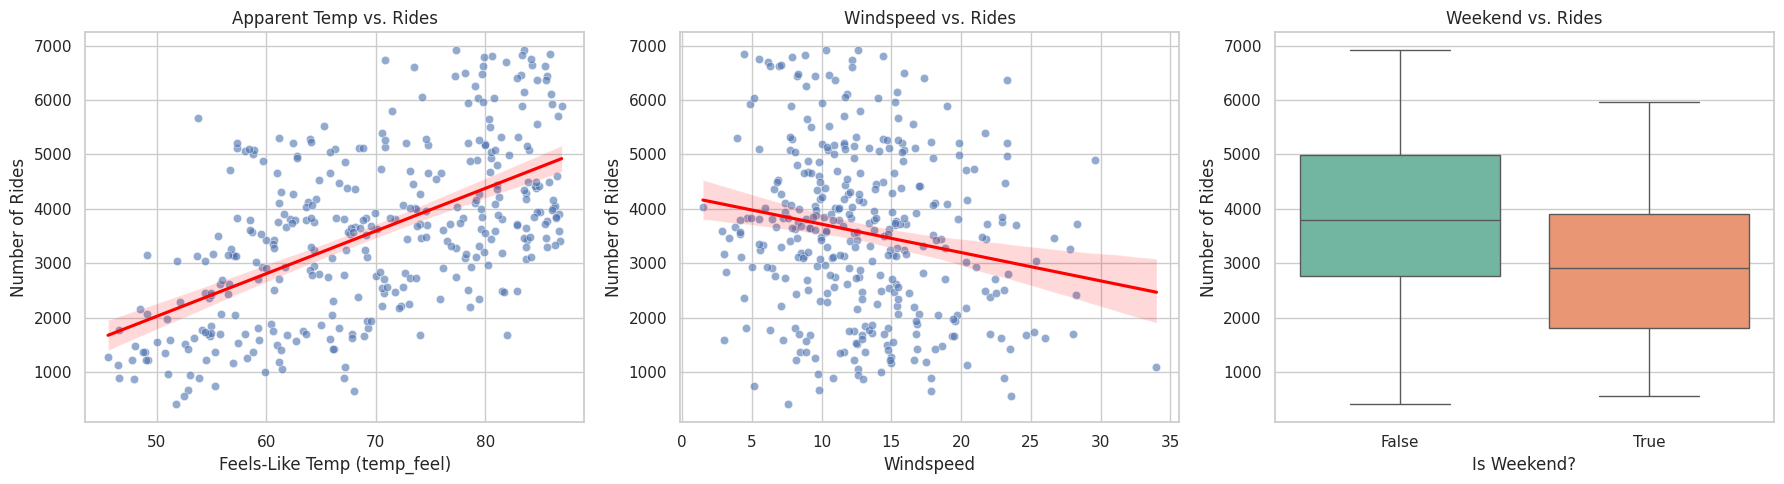

In [ ]:
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. First: Split the dataset (70% Train, 30% Test)
train_df, test_df = train_test_split(bikes, test_size=0.2, random_state=42)

# Set up visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Numeric Continuous (temp_feel vs rides) ---
sns.scatterplot(
    data=train_df, x="temp_feel", y="rides", alpha=0.6, ax=axes[0]
)
sns.regplot(
    data=train_df,
    x="temp_feel",
    y="rides",
    scatter=False,
    color="red",
    ax=axes[0],
)
axes[0].set_title("Apparent Temp vs. Rides")
axes[0].set_xlabel("Feels-Like Temp (temp_feel)")
axes[0].set_ylabel("Number of Rides")

# --- Plot 2: Numeric Continuous (windspeed vs rides) ---
sns.scatterplot(
    data=train_df, x="windspeed", y="rides", alpha=0.6, ax=axes[1]
)
sns.regplot(
    data=train_df,
    x="windspeed",
    y="rides",
    scatter=False,
    color="red",
    ax=axes[1],
)
axes[1].set_title("Windspeed vs. Rides")
axes[1].set_xlabel("Windspeed")
axes[1].set_ylabel("Number of Rides")

# --- Plot 3: Binary Categorical (weekend vs rides) ---
sns.boxplot(
    data=train_df,
    x="weekend",
    y="rides",
    hue="weekend",
    palette="Set2",
    legend=False,
    ax=axes[2],
)
axes[2].set_title("Weekend vs. Rides")
axes[2].set_xlabel("Is Weekend?")
axes[2].set_ylabel("Number of Rides")

plt.tight_layout()
plt.show()


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
X = bikes[['temp_feel', 'windspeed', 'weekend']]
y = bikes['rides']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Intercept: {model.intercept_:.4f}")
for col, coef in zip(X.columns, model.coef_):
    print(f"Coefficient ({col}): {coef:.4f}")

print(f"Train RMSE: {train_rmse:.4f} | Train R²: {train_r2:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} | Test R²:  {test_r2:.4f}")

Intercept: -1110.8158
Coefficient (temp_feel): 75.0235
Coefficient (windspeed): -28.3106
Coefficient (weekend): -700.2188
Train RMSE: 1195.1987 | Train R²: 0.3908
Test RMSE:  1344.9949 | Test R²:  0.3924


In [7]:
list(zip(X, model.coef_))

[('temp_feel', np.float64(75.02352226591938)),
 ('windspeed', np.float64(-28.310575023875742)),
 ('weekend', np.float64(-700.2188026878292))]

this info was surprising to me at first.
I thought the bikes were motor bikes at first.
knowing they are manual bikes, this makes sense.
people are more likely to bike if the weather is nice (+)
less likely to bike if the wind is high (-)
less likely to bike if its the weekend (-) maybe because less people are Biking to work on the weekend

In [9]:
y_pred = model.predict(X_train)
comparison = pd.DataFrame({"Actual": y_train, "Predicted": y_pred})
print(comparison.head())

     Actual    Predicted
249    2085  2950.676295
433    6898  4924.438281
19      472  2107.290760
322    4571  3066.202283
332    3605  2945.613331


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Calculate Mean Squared Error (MSE) and take the square root for RMSE
mse_train = mean_squared_error(y_train, y_pred)
rmse_train = np.sqrt(mse_train)

# 2. Calculate R² (Coefficient of Determination)
r2_train = r2_score(y_train, y_pred)

# Display the in-sample metrics
print("--- In-Sample (Training) Performance ---")
print(f"RMSE : {rmse_train:.4f}")
print(f"R²   : {r2_train:.4f}")

--- In-Sample (Training) Performance ---
RMSE : 1195.1987
R²   : 0.3908


In [13]:
mse_test =  mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
print(f"rmse test: {rmse_test:.4f} rmse train: {rmse_train:.4f}")
print(f"r2 test: {r2_test:.4f}, r2 train: {r2_train:.4f}")

rmse test: 1344.9949 rmse train: 1195.1987
r2 test: 0.3924, r2 train: 0.3908


this model shows good performance without using generalizations
